# Récupérer des données avec des API depuis Python

Lino Galiana  
2025-03-08

<div class="badge-container"><div class="badge-text">Pour essayer les exemples présents dans ce tutoriel :</div><a href="https://github.com/linogaliana/python-datascientist-notebooks/blob/main/notebooks/manipulation/04c_API_TP.ipynb" target="_blank" rel="noopener"><img src="https://img.shields.io/static/v1?logo=github&label=&message=View%20on%20GitHub&color=181717" alt="View on GitHub"></a>
<a href="https://datalab.sspcloud.fr/launcher/ide/vscode-python?autoLaunch=true&name=«04c_API_TP»&init.personalInit=«https%3A%2F%2Fraw.githubusercontent.com%2Flinogaliana%2Fpython-datascientist%2Fmain%2Fsspcloud%2Finit-vscode.sh»&init.personalInitArgs=«manipulation%2004c_API_TP%20correction»" target="_blank" rel="noopener"><img src="https://custom-icon-badges.demolab.com/badge/SSP%20Cloud-Lancer_avec_VSCode-blue?logo=vsc&logoColor=white" alt="Onyxia"></a>
<a href="https://datalab.sspcloud.fr/launcher/ide/jupyter-python?autoLaunch=true&name=«04c_API_TP»&init.personalInit=«https%3A%2F%2Fraw.githubusercontent.com%2Flinogaliana%2Fpython-datascientist%2Fmain%2Fsspcloud%2Finit-jupyter.sh»&init.personalInitArgs=«manipulation%2004c_API_TP%20correction»" target="_blank" rel="noopener"><img src="https://img.shields.io/badge/SSP%20Cloud-Lancer_avec_Jupyter-orange?logo=Jupyter&logoColor=orange" alt="Onyxia"></a>
<a href="https://colab.research.google.com/github/linogaliana/python-datascientist-notebooks-colab//blob/main//notebooks/manipulation/04c_API_TP.ipynb" target="_blank" rel="noopener"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"></a><br></div>

<div class="callout callout-style-default callout-note callout-titled">
<div class="callout-header d-flex align-content-center">
<div class="callout-icon-container"><i class="callout-icon"></i>
</div>
<div class="callout-title-container flex-fill">
Version 🇫🇷
</div>
</div>
<div class="callout-body-container callout-body">
This is the French version 🇫🇷 of that chapter,to see the English version go <a href="https://pythonds.linogaliana.fr/content/manipulation/04c_API_TP.html">there</a>
</div>
</div>

# 1. Introduction : Qu’est-ce qu’une API ?

Nous avons vu dans les chapitres précédents comment consommer des données depuis un fichier (le mode d’accès le plus simple) ou comment récupérer des données par le biais du *webscraping*, une méthode qui permet à `Python` de singer le comportement d’un navigateur web et de récupérer de l’information en moissonnant le HTML auquel accède un site web.

Le webscraping est un pis-aller pour accéder à de la donnée. Heureusement, il existe d’autres manières d’accéder à des données : les API de données. En informatique, une API est un ensemble de protocoles permettant à deux logiciels de communiquer entre eux. Par exemple, on parle parfois d’API Pandas ce qui désigne le fait que `Pandas` est une interface entre votre code `Python` et un langage compilé plus efficace (`C`) qui fait les calculs que vous demandez au niveau de `Python`. L’objectif d’une API est ainsi de fournir un point d’accès à une fonctionnalité qui soit facile à utiliser et qui masque les détails de la mise en oeuvre.

Dans ce chapitre, nous nous intéressons principalement aux API de données. Ces dernières sont simplement une façon de mettre à disposition des données : plutôt que de laisser l’utilisateur consulter directement des bases de données (souvent volumineuses et complexes), l’API lui propose de formuler une requête qui est traitée par le serveur hébergeant la base de données, puis de recevoir des données en réponse à sa requête.

L’utilisation accrue d’API dans le cadre de stratégies open-data est l’un
des piliers des 15 feuilles de route ministérielles françaises
en matière d’ouverture, de circulation et de valorisation des données publiques.

<div class="alert alert-info" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-comment"></i> Note</h3>

Depuis quelques années, un service officiel de géocodage a été mis en place pour le territoire français.
Celui-ci est gratuit et permet de manière efficace de coder des adresses
à partir d’une API. Cette API, connue sous le
nom de la **Base d’Adresses Nationale (BAN)** a bénéficié de la mise en commun de données de plusieurs
acteurs (collectivités locales, Poste, IGN) et de compétences d’acteurs
comme Etalab. La documentation de celle-ci est disponible à l’adresse
<https://api.gouv.fr/les-api/base-adresse-nationale>.

</div>

On prend souvent comme exemple pour illustrer les API l’exemple du restaurant. La documentation est votre menu : elle liste les plats (les bases de données) que vous pouvez commander et les éventuels ingrédients de celle-ci que vous pouvez choisir (les paramètres de votre requête) : poulet, boeuf ou option végé ? Lorsque vous faites ceci, vous ne connaissez pas la recette utilisée en arrière cuisine pour faire votre plat: vous recevez seulement celui-ci. De manière logique, plus le plat que vous avez demandé est raffiné (calculs complexes côté serveur), plus votre plat mettra du temps à vous arriver.

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-lightbulb"></i> Illustration avec l’API BAN</h3>

Pour illustrer ceci, imaginons ce qu’il se passe lorsque, dans la suite du chapitre, nous ferons des requêtes à l’API BAN.

Via `Python`, on envoie notre commande à celle-ci: des adresses plus ou moins complètes avec des instructions annexes comme le code commune. Ces instructions annexes peuvent s’apparenter à des informations fournies au serveur du restaurant comme des interdits alimentaires qui vont personnaliser la recette.

A partir de ces instructions, le plat est lancé. En l’occurrence, il s’agit de faire tourner sur les serveurs d’Etalab une routine qui va chercher dans un référentiel d’adresse celle qui est la plus similaire à celle qu’on a demandé en adaptant éventuellement en fonction des instructions annexes qu’on a fourni. Une fois que côté cuisine on a fini cette préparation, on renvoie le plat au client. En l’occurrence, le plat sera des coordonnées géographiques qui correspondent à l’adresse la plus similaire.

Le client n’a donc qu’à se préoccuper de faire une bonne requête et d’apprécier le plat qui lui est fourni. L’intelligence dans la mise en oeuvre est laissée aux spécialistes qui ont conçu l’API. Peut-être que d’autres spécialistes, par exemple Google Maps, mettent en oeuvre une recette différente pour ce même plat (des coordonnées géographiques) mais ils vous proposeront probablement un menu très similaire. Ceci vous simplifie beaucoup la vie: il vous suffit de changer quelques lignes de code d’appel à une API plutôt que de modifier un ensemble long et complexe de méthodes d’identification d’adresses.

</div>

## Approche pédagogique

Après une première présentation du principe général des API, ce chapitre illustre l’usage de celles-ci via `Python` par le biais d’un *use case* assez standard: on dispose d’un jeu de données qu’on désire d’abord géolocaliser. Pour cela, on va demander à une API de nous renvoyer des coordonnées géographiques à partir d’adresses. Ensuite on ira chercher des informations un peu plus complexes par le biais d’autres API.

# 2. Première utilisation d’API

Une API a donc vocation à servir d’intermédiaire entre un client et un serveur. Ce client peut être de deux types: une interface web ou un logiciel de programmation. L’API ne fait pas d’*a priori* sur l’outil qui sert lui passe une commande, elle lui demande seulement de respecter un standard (en général une requête http), une structure de requête (les arguments) et d’attendre le résultat.

## 2.1 Comprendre le principe avec un exemple interactif

Le premier mode (accès par un navigateur) est principalement utilisé lorsqu’une interface web permet à un utilisateur de faire des choix afin de lui renvoyer des résultats correspondant à ceux-ci. Prenons à nouveau l’exemple de l’API de géolocalisation que nous utiliserons dans ce chapitre. Imaginons une interface web permettant à l’utilisateur deux choix: un code postal et une adresse. Cela sera injecté dans la requête et le serveur répondra avec la géolocalisation adaptée.

<div class="alert alert-danger" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-triangle-exclamation"></i> Important</h3>

Une explication interactive est disponible sur [le site du cours](https://pythonds.linogaliana.fr/content/manipulation/04c_API_TP.html).

</div>

## 2.2 Comment faire avec `Python` ?

Le principe est le même sauf que nous perdons l’aspect interactif. Il s’agira donc, avec `Python`, de construire l’URL voulue et d’aller chercher via une requête HTTP le résultat.

Nous avons déjà vu dans le chapitre de webscraping la manière dont `Python` communique avec internet: via le *package* `requests`. Ce *package* suit le protocole HTTP où on retrouve principalement deux types de requêtes: `GET` et `POST`:

-   La requête `GET` est utilisée pour récupérer des données depuis un serveur web. C’est la méthode la plus simple et courante pour accéder aux ressources d’une page web. Nous allons commencer par décrire celle-ci.
-   La requête `POST` est utilisée pour envoyer des données au serveur, souvent dans le but de créer ou de mettre à jour une ressource. Sur les pages web, elle sert souvent à la soumission de formulaires qui nécessitent de mettre à jour des informations sur une base (mot de passe, informations clients, etc.). Nous verrons son utilité plus tard, lorsque nous commencerons à rentrer dans les requêtes authentifiées où il faudra soumettre des informations supplémentaires à notre requête.

Faisons un premier test avec `Python` en faisant comme si nous connaissions bien cette API.

In [1]:
import requests

url_ban_example = (
    "https://api-adresse.data.gouv.fr/search/?q=88+avenue+verdier&postcode=92120"
)
requests.get(url_ban_example)


Qu’est-ce qu’on obtient ? Un code HTTP. Le code 200 correspond aux requêtes réussies, c’est-à-dire pour lesquelles le serveur est en mesure de répondre. Si ce n’est pas le cas, pour une raison *x* ou *y*, vous aurez un code différent.

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-lightbulb"></i> Les codes HTTP</h3>

Les codes de statut HTTP sont des réponses standard envoyées par les serveurs web pour indiquer le résultat d’une requête effectuée par un client (comme un navigateur ou un script Python). Ils sont classés en différentes catégories selon le premier chiffre du code :

-   1xx : Informations
-   2xx : Succès
-   3xx : Redirections
-   4xx : Erreurs côté client
-   5xx : Erreurs côté serveur

Ceux à retenir sont : 200 (succès), 400 (requête mal structurée), 401 (authentification non réussie), 403 (accès interdit), 404 (ressource demandée n’existe pas), 503 (le serveur n’est pas en capacité de répondre)

</div>

Pour récupérer le contenu renvoyé par `requests`, il existe plusieurs méthodes. Quand on un JSON bien formatté, le plus simple est d’utiliser la méthode `json` qui transforme cela en dictionnaire :

In [2]:
req = requests.get(url_ban_example)
localisation_insee = req.json()
localisation_insee


En l’occurrence, on voit que les données sont dans un JSON imbriqué. Il faut donc développer un peu de code pour récupérer les informations voulues dans celui-ci:

In [3]:
localisation_insee.get("features")[0].get("properties")


C’est là l’inconvénient principal de l’usage des API: le travail *ex post* sur les données renvoyées. Le code nécessaire est propre à chaque API puisque l’architecture du JSON dépend de chaque API.

## 2.3 Comment connaître les *inputs* et *outputs* des API ?

Ici on a pris l’API BAN comme un outil magique dont on connaissait les principaux *inputs* (l’*endpoint*, les paramètres et leur formattage…).
Mais comment faire, en pratique, pour en arriver là ? Tout simplement en lisant la documentation lorsqu’elle existe et en testant celle-ci via des exemples.

Les bonnes API proposent un outil interactif qui s’appelle le [`swagger`](https://swagger.io/docs/). C’est un site web interactif où sont décrites les principales fonctionnalités de l’API et où l’utilisateur peut tester des exemples interactivement. Ces documentations sont souvent créées automatiquement lors de la construction d’une API et mises à disposition par le biais d’un point d’entrée `/docs`. Elles permettent souvent d’éditer certains paramètres dans le navigateur, voir le JSON obtenu (ou l’erreur générée) et récupérer la requête formattée qui permet d’obtenir celui-ci. Ces consoles interactives dans le navigateur permettent de répliquer le tâtonnement qu’on peut faire par ailleurs dans des outils spécialisés comme [`postman`](https://www.postman.com/).

Concernant l’API BAN, la documentation se trouve sur <https://adresse.data.gouv.fr/api-doc/adresse>. Elle n’est pas interactive, malheureusement. Mais elle présente de nombreux exemples qui peuvent être testés directement depuis le navigateur. Il suffit d’utiliser les URL proposées comme exemple. Ceux-ci sont présentés par le biais de `curl` (un équivalent de `requests` en ligne de commande Linux):

``` python
curl "https://api-adresse.data.gouv.fr/search/?q=8+bd+du+port&limit=15"
```

Il suffit de copier l’URL en question (`https://api-adresse.data.gouv.fr/search/?q=8+bd+du+port&limit=15`), d’ouvrir un nouvel onglet et vérifier que cela produit bien un résultat. Puis de changer un paramètre et vérifier à nouveau, jusqu’à trouver la structure qui convient. Et après, on peut passer à `Python` comme le propose l’exercice suivant.

## 2.4 Application

Pour commencer cet exercice, vous aurez besoin de cette variable:

In [4]:
adresse = "88 Avenue Verdier"


<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice 1: Structurer un appel à une API depuis Python</h3>

1.  Tester sans aucun autre paramètre, le retour de notre API. Transformer en `DataFrame` le résultat.
2.  Se restreindre à Montrouge avec le paramètre *ad hoc* et la recherche du code insee ou code postal adéquat sur google.
3.  (Optionnel): Représenter l’adresse trouvée sur une carte

</div>

In [6]:
import requests
import pandas as pd

ban_root = "https://api-adresse.data.gouv.fr"
ban_search_endpoint = "search"
api_ban_q1 = f"{ban_root}/{ban_search_endpoint}?q={adresse.replace(" ", "+")}"
output_api_ban = requests.get(api_ban_q1).json().get("features")

df_avenue_verdier = pd.DataFrame([out["properties"] for out in output_api_ban])


Les deux premières lignes du *dataframe* obtenu à la question 1 devraient être

In [7]:
df_avenue_verdier.head(2)


A la question 2, on ressort cette fois qu’une seule observation, qu’on pourrait retravailler avec `GeoPandas` pour vérifier qu’on a bien placé ce point sur une carte

In [8]:
api_ban_q2 = (
    f"{ban_root}/{ban_search_endpoint}?q={adresse.replace(" ", "+")}&postcode=92120"
)
output_q2 = requests.get(api_ban_q2).json()


In [9]:
import pandas as pd
import geopandas as gpd

output_q2 = pd.DataFrame([output_q2.get("features")[0]["properties"]])
output_q2 = gpd.GeoDataFrame(
    output_q2, geometry=gpd.points_from_xy(output_q2.x, output_q2.y), crs="EPSG:2154"
).to_crs(4326)
output_q2


Enfin, à la question 3, on obtient cette carte (plus ou moins la même que précédemment):

In [10]:
import folium

# Extraire la longitude et la latitude
longitude = output_q2.geometry.x.iloc[0]
latitude = output_q2.geometry.y.iloc[0]

# Créer une carte Folium centrée sur le point
m = folium.Map(location=[latitude, longitude], zoom_start=16)

# Définir le contenu de la popup
popup_content = f"""
<b>{output_q2['name'].iloc[0]}</b> has been found!
"""

# Ajouter le marqueur
folium.Marker(
    location=[latitude, longitude],
    popup=folium.Popup(popup_content, max_width=300),
    icon=folium.Icon(color="blue", icon="info-sign"),
).add_to(m)

# Afficher la carte dans le notebook (si utilisé dans un Jupyter Notebook)
m


<div class="alert alert-info" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-comment"></i> Quelques API à connaître</h3>

Les principaux fournisseurs de données officielles proposent des API. C’est le cas notamment de l’[Insee](https://api.insee.fr/catalogue/), d’[Eurostat](https://wikis.ec.europa.eu/display/EUROSTATHELP/API+-+Getting+started), de la [BCE](https://data.ecb.europa.eu/help/data-examples), de la [FED](https://fred.stlouisfed.org/docs/api/fred/), de la [Banque Mondiale](https://datahelpdesk.worldbank.org/knowledgebase/topics/125589)…

Néanmoins, la production de données par les institutions étatiques est loin d’être restreinte aux producteurs de statistiques publiques. Le portail [API gouv](https://api.gouv.fr/) est le point de référencement principal pour les API produites par l’administration centrale française ou des administrations territoriales. De nombreuses villes publient également des données sur leurs infrastructures par le biais d’API, par exemple la [ville de Paris](https://opendata.paris.fr/api/explore/v2.1/console).

Les producteurs de données privées proposent également des API. Par exemple, la [SNCF](https://data.sncf.com/api) ou la [RATP](https://data.ratp.fr/pages/temps-reel/) proposent des API pour certains usages. Les grands acteurs du numérique, par exemple [`Spotify` ](https://developer.spotify.com/web-api/) proposent généralement des API pour intégrer certains de leurs services à des applications externes.

Cependant, il faut être conscient des limites de certaines API. En premier lieu, les données partagées ne sont pas forcément très riches pour ne pas compromettre la confidentialité des informations partagées par les utilisateurs du service ou la part de marché du producteur qui n’a pas intérêt à vous partager ses données à forte valeur. Il faut également être conscient du fait qu’une API peut disparaître ou changer de structure du jour au lendemain. Les codes de restructuration de données étant assez adhérents à une structure d’API, on peut se retrouver à devoir changer un volume conséquent de code si une API critique change substantiellement.

</div>

# 3. Plus d’exemples de requêtes `GET`

## 3.1 Source principale

Nous allons utiliser comme base principale pour ce tutoriel la [base permanente des équipements](https://www.insee.fr/fr/metadonnees/source/serie/s1161), un répertoire d’équipements publics accueillant du public.

On va commencer par récupérer les données qui nous intéressent. On ne récupère pas toutes les variables du fichier mais seulement celles qu’ils nous intéressent: quelques variables sur l’équipement, son adresse et sa commune d’appartement.

Nous allons nous restreindre aux établissements d’enseignement primaire, secondaire et supérieur du département de la Haute-Garonne (le département 31). Ces établissements sont identifiés par un code particulier, entre `C1` et `C5`.

In [11]:
query = """
FROM read_parquet('https://minio.lab.sspcloud.fr/lgaliana/diffusion/BPE23.parquet')
SELECT NOMRS, NUMVOIE, INDREP, TYPVOIE, LIBVOIE,
       CADR, CODPOS, DEPCOM, DEP, TYPEQU,
       concat_ws(' ', NUMVOIE, INDREP, TYPVOIE, LIBVOIE) AS adresse, SIRET
WHERE DEP = '31'
      AND starts_with(TYPEQU, 'C')
      AND NOT (starts_with(TYPEQU, 'C6') OR starts_with(TYPEQU, 'C7'))
"""

import duckdb

bpe = duckdb.sql(query)
bpe = bpe.to_df()


## 3.2 Récupérer des données à façon grâce aux API

Nous avons vu précédemment le principe général d’une requête d’API. Pour illustrer, de manière plus massive, la récupération de données par le biais d’une API, essayons de récupérer des données complémentaires à notre source principale. Nous allons utiliser l’annuaire de l’éducation qui fournit de nombreuses informations sur les établissements scolaires. Nous utiliserons le SIRET pour croiser les deux sources de données.

L’exercice suivant viendra illustrer l’intérêt d’utiliser une API pour avoir des données à façon et la simplicité à récupérer celles-ci via `Python`. Néanmoins, cet exercice illustrera également une des limites de certaines API, à savoir la volumétrie des données à récupérer.

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice 2</h3>

1.  Visiter le *swagger* de l’API de l’Annuaire de l’Education nationale sur [api.gouv.fr/documentation](https://api.gouv.fr/documentation/api-annuaire-education) et tester une première récupération de données en utilisant le *endpoint* `records` sans aucun paramètre.
2.  Puisqu’on n’a conservé que les données de la Haute Garonne dans notre base principale, on désire ne récupérer que les établissements de ce département par le biais de notre API. Faire une requête avec le paramètre *ad hoc*, sans en ajouter d’autres.
3.  Augmenter la limite du nombre de paramètres, voyez-vous le problème ?
4.  On va tenter de récupérer ces données par le biais de l’API tabular de `data.gouv`. Sa documentation est [ici](https://tabular-api.data.gouv.fr/api/doc) et l’identifiant de la ressource est `b22f04bf-64a8-495d-b8bb-d84dbc4c7983` ([source](https://www.data.gouv.fr/fr/datasets/annuaire-de-leducation/)). Avec l’aide de la documentation, essayer de récupérer des données par le biais de cette API en utilisant le paramètre `Code_departement__exact=031` pour ne garder que le département d’intérêt.
5.  Voyez-vous le problème et comment nous pourrions automatiser la récupération de données ?

</div>

La première question nous permet de récupérer un premier jeu de données

In [12]:
import requests

url_annuaire_education = "https://data.education.gouv.fr/api/explore/v2.1/catalog/datasets/fr-en-annuaire-education/records"

school_q1_exo2 = pd.DataFrame(
    requests.get(url_annuaire_education).json().get("results")
)

school_q1_exo2.head(2)


Néanmoins, on a deux problèmes : le nombre de lignes et le département d’intérêt. Essayons déjà avec la question 2 de changer ce dernier.

In [13]:
url_31_limite10 = "https://data.education.gouv.fr/api/explore/v2.1/catalog/datasets/fr-en-annuaire-education/records?where=code_departement%20like%20%22031%22"

school_q2_exo2 = pd.DataFrame(requests.get(url_31_limite10).json().get("results"))
school_q2_exo2.head()


C’est mieux, mais nous avons toujours seulement 10 observations. Si on essaie d’ajuster le nombre de lignes (question 3), on obtient le retour suivant de l’API :

In [14]:
url_31_limite200 = "https://data.education.gouv.fr/api/explore/v2.1/catalog/datasets/fr-en-annuaire-education/records?where=code_departement%20like%20%22031%22&limit=200"

requests.get(url_31_limite200).content


Essayons avec des données plus exhaustives : le fichier brut sur `data.gouv`. Comme on peut le voir dans les métadonnées, on sait qu’on a plus de 1000 écoles dont on peut récupérer des données, mais qu’on en a ici extrait seulement 20. Le champ `next` nous donne directement l’URL à utiliser pour récupérer les 20 pages suivantes : c’est grâce à lui qu’on a une chance de récupérer toutes nos données d’intérêt.

In [15]:
url_api_datagouv = "https://tabular-api.data.gouv.fr/api/resources/b22f04bf-64a8-495d-b8bb-d84dbc4c7983/data/?Code_departement__exact=031"

call_api_datagouv = requests.get(url_api_datagouv).json()


La partie intéressante pour automatiser la récupération de nos données est la clé `links` du JSON :

In [16]:
call_api_datagouv.get("links")


En bouclant sur celui-ci pour parcourir la liste des URL accessibles, on peut récupérer des données. Comme le code d’automatisation est assez fastidieux à écrire, le voici :

In [17]:
import requests
import pandas as pd

# Initialize the initial API URL
url_api_datagouv = "https://tabular-api.data.gouv.fr/api/resources/b22f04bf-64a8-495d-b8bb-d84dbc4c7983/data/?Code_departement__exact=031&page_size=50"

# Initialize an empty list to store all data entries
all_data = []

# Initialize the URL for pagination
current_url = url_api_datagouv

# Loop until there is no next page
while current_url:
    try:
        # Make a GET request to the current URL
        response = requests.get(current_url)
        response.raise_for_status()  # Raise an exception for HTTP errors

        # Parse the JSON response
        json_response = response.json()

        # Extract data and append to the all_data list
        page_data = json_response.get("data", [])
        all_data.extend(page_data)
        print(f"Fetched {len(page_data)} records from {current_url}")

        # Get the next page URL
        links = json_response.get("links", {})
        current_url = links.get("next")  # This will be None if there's no next page

    except requests.exceptions.RequestException as e:
        print(f"An error occurred: {e}")
        break


Le *DataFrame* obtenu est le suivant:

In [18]:
schools_dep31 = pd.DataFrame(all_data)
schools_dep31.head()


On peut fusionner ces nouvelles données avec nos données précédentes pour enrichir celles-ci. Pour faire une production fiable, il faudrait faire attention aux écoles qui ne s’apparient pas, mais ce n’est pas grave pour cette série d’exercices.

In [19]:
bpe_enriched = bpe.merge(schools_dep31, left_on="SIRET", right_on="SIREN_SIRET")
bpe_enriched.head(2)


Cela nous donne des données enrichies de nouvelles caractéristiques sur les établissements. Il y a des coordonnées géographiques dans celles-ci, mais nous allons faire comme s’il n’y en avait pas pour réutiliser notre API de géolocalisation.

# 4. Découverte des requêtes `POST`

## 4.1 Logique

Nous avons jusqu’à présent évoqué les requêtes `GET`. Nous allons maintenant présenter les requêtes `POST` qui permettent d’interagir de manière plus complexe avec des serveurs de l’API.

Pour découvrir celles-ci, nous allons reprendre l’API de géolocalisation précédente mais utiliser un autre point d’entrée qui nécessite une requête `POST`.

Ces dernières sont généralement utilisées quand il est nécessaire d’envoyer des données particulières pour déclencher une action. Par exemple, dans le monde du web, si vous avez une authentification à mettre en oeuvre, une requête `POST` permettra d’envoyer un *token* au serveur qui répondra en acceptant votre authentification.

Dans notre cas, nous allons envoyer des données au serveur, ce dernier va les recevoir, les utiliser pour la géolocalisation puis nous envoyer une réponse. Pour continuer sur la métaphore culinaire, c’est comme si vous donniez vous-mêmes à la cuisine un *tupperware* pour récupérer votre plat à emporter.

## 4.2 Principe

Prenons cette requête proposée sur le site de documentation de l’API de géolocalisation:

``` bash
curl -X POST -F data=@path/to/file.csv -F columns=voie -F columns=ville -F citycode=ma_colonne_code_insee https://api-adresse.data.gouv.fr/search/csv/
```

Comme nous avons pu l’évoquer précédemment, `curl` est un outil en ligne de commande qui permet de faire des requêtes API. L’option `-X POST` indique, de manière assez transparente, qu’on désire faire une requête `POST`.

Les autres arguments sont passés par le biais des options `-F`. En l’occurrence, on envoie un fichier et on ajoute des paramètres pour aider le serveur à aller chercher la donnée dedans. L’`@` indique que `file.csv` doit être lu sur le disque et envoyé dans le corps de la requête comme une donnée de formulaire.

## 4.3 Application avec `Python`

Nous avions `requests.get`, il est donc logique que nous ayons `requests.post`. Cette fois, il faudra passer des paramètres à notre requête sous la forme d’un dictionnaire dont les clés sont le nom de l’argument et les valeurs sont des objets `Python`.

Le principal défi, illustré dans le prochain exercice, est le passage de l’argument `data`: il faudra renvoyer le fichier comme un objet `Python` par le biais de la fonction `open`.

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice 3: une requête POST pour géolocaliser en masse nos données</h3>

1.  Enregistrer au format CSV les colonnes `adresse`, `DEPCOM` et `Nom_commune` de la base d’équipements fusionnée avec notre répertoire précédent (objet `bpe_enriched`). Il peut être utile, avant l’écriture au format CSV, de remplacer les virgules dans la colonne `adresse` par des espaces.
2.  Créer l’objet `response` avec `requests.post` et les bons arguments pour géocoder votre CSV.
3.  Transformer votre output en objet `geopandas` avec la commande suivante:

``` python
bpe_loc = pd.read_csv(io.StringIO(response.text))
```

</div>

In [20]:
import pathlib

output_path = pathlib.Path("data/output")
output_path.mkdir(parents=True, exist_ok=True)
csv_file = output_path / "bpe_before_geoloc.csv"

bpe_enriched["adresse"] = bpe_enriched["adresse"].str.replace(",", "")

bpe_enriched.loc[:, ["adresse", "DEPCOM", "Nom_commune"]].to_csv(csv_file)


In [21]:
import io

params = {
    "columns": ["adresse", "Nom_commune"],
    "citycode": "DEPCOM",
    "result_columns": ["result_score", "latitude", "longitude"],
}

response = requests.post(
    "https://api-adresse.data.gouv.fr/search/csv/",
    data=params,
    files={"data": open(csv_file, "rb")},
)


bpe_loc = pd.read_csv(io.StringIO(response.text))
bpe_loc = bpe_loc.rename({"Unnamed: 0": "index"}, axis="columns")


Les géolocalisations obtenues prennent cette forme

In [22]:
bpe_loc.head(2)


En enrichissant les données précédentes, cela donne:

In [23]:
bpe_loc = bpe_loc.loc[:, ["index", "result_score", "latitude", "longitude"]]
bpe_enriched_geocoded = (
    bpe_enriched.reset_index()
    .merge(bpe_loc, on="index", suffixes=["_annuaire", "_ban"])
    .drop("index", axis="columns")
)

bpe_enriched_geocoded.head(2)


On peut vérifier que la géolocalisation ne soit pas trop délirante en comparant avec les longitudes et latitudes de l’annuaire de l’éducation ajouté précédemment:

In [24]:
pd.concat(
    [
        bpe_enriched_geocoded.loc[:, ["NOMRS", "Nom_commune"]],
        bpe_enriched_geocoded.filter(like="longitude"),
        bpe_enriched_geocoded.filter(like="latitude"),
    ],
    axis=1,
).sample(5)


Sans rentrer dans le détail, les positions semblent très similaires à quelques imprécisions près.

In [25]:
bpe_enriched_geocoded = bpe_enriched_geocoded.dropna(
    subset=["longitude_ban", "latitude_ban"]
)

bpe_enriched_geocoded = gpd.GeoDataFrame(
    bpe_enriched_geocoded,
    geometry=gpd.points_from_xy(
        bpe_enriched_geocoded["longitude_ban"], bpe_enriched_geocoded["latitude_ban"]
    ),
    crs="EPSG:4326",
)


Pour profiter de nos données enrichies, on peut faire une carte. Pour ajouter un peu de contexte à celle-ci, on peut mettre un fond de carte des communes en arrière plan. Celui-ci peut être récupéré avec `cartiflette`:

In [26]:
from cartiflette import carti_download

shp_communes = carti_download(
    crs=4326,
    values=["31"],
    borders="COMMUNE",
    vectorfile_format="topojson",
    filter_by="DEPARTEMENT",
    source="EXPRESS-COG-CARTO-TERRITOIRE",
    year=2022,
)
shp_communes.crs = 4326


Représentées sur une carte, cela donne la carte suivante:

In [27]:
import folium
from folium.plugins import MarkerCluster
import geopandas as gpd

department_border = shp_communes.dissolve(by="INSEE_DEP")
city_borders = shp_communes.copy()

longitude = bpe_enriched_geocoded.geometry.x.iloc[0]
latitude = bpe_enriched_geocoded.geometry.y.iloc[0]
m = folium.Map(location=[latitude, longitude], zoom_start=10)

# Add department border (black, bold)
folium.GeoJson(
    data=department_border,
    style_function=lambda x: {
        "fill": False,
        "color": "black",
        "weight": 3,  # Bold border
    },
).add_to(m)

# Add city borders (blue, thin)
folium.GeoJson(
    data=city_borders,
    style_function=lambda x: {
        "fill": False,
        "color": "blue",
        "weight": 1,  # Thin border
    },
).add_to(m)

# Initialize the MarkerCluster
marker_cluster = MarkerCluster().add_to(m)


def generate_popup(row):
    # Initialiser le contenu avec le nom de l'école
    popup_content = f"<b>Nom:</b> {row['NOMRS']}<br>"

    # Ajouter "Ecole élémentaire" avec une icône ✅️ ou ❌️ selon la valeur
    ecole_element_status = "✅️" if row.get("Ecole_elementaire", False) else "❌️"
    popup_content += f"<b>Ecole élémentaire:</b> {ecole_element_status}<br>"

    # Ajouter "Nombre d'élèves" si disponible
    if not pd.isnull(row.get("Nombre_d_eleves")):
        popup_content += f"<b>Nombre d'élèves:</b> {row['Nombre_d_eleves']}<br>"

    # Ajouter "Voie générale" si disponible
    if not pd.isnull(row.get("Voie_generale")):
        popup_content += f"<b>Voie générale:</b> {row['Voie_generale']}<br>"

    # Ajouter "Voie technologique" si disponible
    if not pd.isnull(row.get("Voie_technologique")):
        popup_content += f"<b>Voie technologique:</b> {row['Voie_technologique']}<br>"

    return popup_content


# Add GeoDataFrame points to the MarkerCluster
for _, row in bpe_enriched_geocoded.iterrows():
    # Create the popup content
    popup_content = generate_popup(row)

    popup = folium.Popup(popup_content, max_width=300)

    # Add the marker to the cluster
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],  # Extract latitude and longitude
        popup=popup,
        icon=folium.Icon(color="blue", icon="info-sign"),
    ).add_to(marker_cluster)

# Display the map inline (optional for Jupyter Notebooks)
m


# 5. Gestion des secrets et des exceptions

Nous avons déjà utilisé plusieurs API. Néanmoins ces dernières étaient toutes sans authentification et présentent peu de restrictions, hormis le nombre d’échos. Ce n’est pas le cas de toutes les API. Il est fréquent que les API qui permettent d’aspirer plus de données ou d’accéder à des données confidentielles nécessitent une authentification pour tracer les utilisateurs de données.

Cela se fait généralement par le biais d’un *token*. Ce dernier est une sorte de mot de passe, souvent utilisé dans les systèmes modernes d’authentification pour certifier de l’identité d’un utilisateur.trice (cf. [chapitre `Git`](../../content/git/introgit.qmd)).

Pour illustrer l’usage des *tokens*, nous allons utiliser une API de l’INPI (Institut national de la protection intellectuelle). Les API développées par cette organisation nécessitent en effet une authentification. Nous allons utiliser cette API pour récupérer des documents PDF issus des comptes sociaux des entreprises.

Avant d’en arriver là, nous allons faire un aparté sur la confidentialité des tokens et la manière d’éviter de révéler ceux-ci dans votre code.

## 5.1 Utiliser un token dans un code sans le révéler

Les tokens sont des informations personnelles qui ne doivent pas être partagées. Ils n’ont pas vocation à être présent dans le code. Comme ceci est évoqué à plusieurs reprises dans le cours de [mise en production](https://ensae-reproductibilite.github.io/website/) que Romain Avouac et moi donnons en 3e année, il est important de séparer le code des éléments de configuration

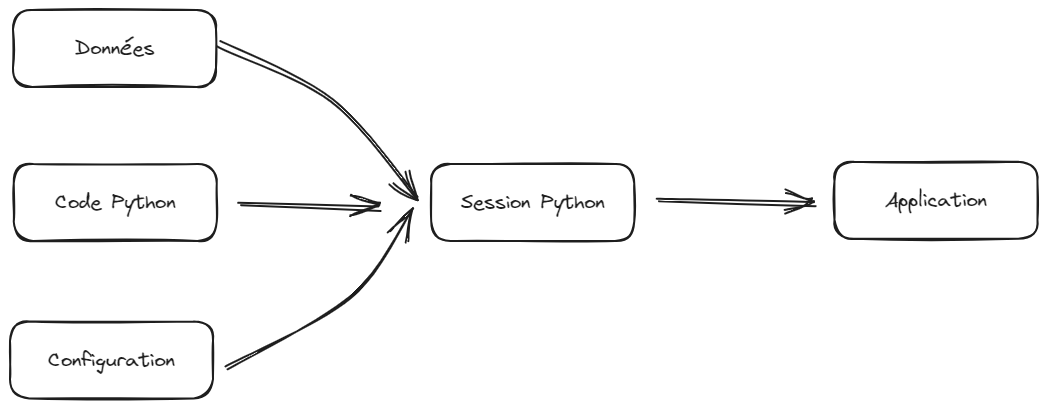

L’idée est de trouver une recette pour apporter les éléments de configuration avec le code mais sans mettre ceux-ci en clair dans le code. L’idée générale sera de stocker la valeur du *token* dans une variable mais ne jamais révéler celle-ci dans le code. Comment faire dès lors pour déclarer la valeur du jeton sans que celui-ci soit apparent dans le code ?

-   Pour un code amené à fonctionner de manière interactive (par exemple par le biais d’un *notebook*), il est possible de créer une boite de dialogue qui injectera la valeur renseignée dans une variable. Cela se fait par le biais du package `getpass`.
-   Pour le code qui tourne en non interactif, par exemple par le biais de la ligne de commande, l’approche par variable d’environnement est la plus fiable, à condition de faire attention à ne pas mettre le fichier de mot de passe dans `Git`.

L’exercice suivant permettra de mettre en oeuvre ces deux méthodes. Ces méthodes nous serviront à ajouter de manière confidentielle un *payload* à des requêtes d’authentification, c’est-à-dire des informations confidentielles identifiantes en complément d’une requête.

## 5.2 Application

Pour cette application, à partir de la question 4, nous allons avoir besoin de créer une classe spéciale permettant à `requests` de surcharger notre requête d’un jeton d’authentification. Comme elle n’est pas triviale à créer sans connaissance préalable, la voici:

In [28]:
class BearerAuth(requests.auth.AuthBase):
    def __init__(self, token):
        self.token = token

    def __call__(self, r):
        r.headers["authorization"] = "Bearer " + self.token
        return r


Nous allons aussi avoir besoin de cette variable qui correspond au Siren de Decathlon

In [29]:
siren = "500569405"


<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice 4: ajouter un payload à une requête</h3>

1.  Se créer un compte pour l’API de l’INPI (Institut national de la protection intellectuelle) qui nous servira à récupérer des bilans des comptes sociaux d’entreprises au format PDF.
2.  Créer les variables `username` et `password` avec `getpass` en faisant en sorte de ne pas rentrer les valeurs dans le code.
3.  En utilisant la [documentation de l’API](https://www.inpi.fr/sites/default/files/documentation%20technique%20API_comptes_annuels%20v4_0.pdf), l’argument `json` de `requests.post`, récupérer un jeton d’authentification et le stocker dans une variable `token`.
4.  Récupérer les données en utilisant la *f-string* `f'https://registre-national-entreprises.inpi.fr/api/companies/{siren}/attachments'` et en donnant à `requests` l’argument `auth=BearerAuth(token)`
5.  Créer `identifier = documents.get('bilans')[0]['id']` et utiliser `requests` avec l’URL `f'https://registre-national-entreprises.inpi.fr/api/bilans/{identifier}/download'`, sans argument, pour récupérer un PDF. Cela a-t-il fonctionné ? Vérifier le *status code*. A quoi correspond-il ? Comment éviter cela ?
6.  En supposant que l’objet `requests.get` créé s’appelle `r`, écrire l’output de notre API dans un PDF de la manière suivante:

``` python
binary_file_path = "decathlon.pdf"
with open(binary_file_path, "wb") as f:
    f.write(r.content)
```

1.  Remplacer l’utilisation de `getpass` par l’approche variable d’environnement grâce à [`dotenv`](https://pypi.org/project/python-dotenv/)

</div>

In [30]:
import os
from dotenv import load_dotenv

load_dotenv()


In [31]:
username = os.getenv("API_INPI_USERNAME")
password = os.getenv("API_INPI_PASSWORD")


In [32]:
import requests

url_login_api = "https://registre-national-entreprises.inpi.fr/api/sso/login"

payload = {"username": username, "password": password}

response = requests.post(url_login_api, json=payload)
token = response.json().get("token")


In [33]:
r = requests.get(
    f"https://registre-national-entreprises.inpi.fr/api/companies/{siren}/attachments",
    auth=BearerAuth(token),
)
documents = r.json()


In [34]:
identifier = documents.get("bilans")[0]["id"]


A la question 5, sans identifiant, on récupère le code erreur 401, qui correspond à *“Unauthorized”*, c’est-à-dire à une requête refusée. Néanmoins, si on ajoute le token comme précédemment, tout se passe bien, on récupère le bilan de Decathlon.

In [35]:
r = requests.get(
    f"https://registre-national-entreprises.inpi.fr/api/bilans/{identifier}/download"
)
r.status_code


In [36]:
r = requests.get(
    f"https://registre-national-entreprises.inpi.fr/api/bilans/{identifier}/download",
    auth=BearerAuth(token),
)


In [37]:
binary_file_path = "decathlon.pdf"
with open(binary_file_path, "wb") as f:
    f.write(r.content)


Le PDF récupéré

<div class="alert alert-danger" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-triangle-exclamation"></i> Important</h3>

L’approche par variable d’environnement est la plus générale et malléable. Il faut néanmoins bien faire attention à ne pas oublier d’ajouter le `.env` stockant les identifiants dans `Git`. Autrement, vous risquez de révéler des informations identifiantes ce qui annule tout effet positif des bonnes pratiques mises en oeuvre avec `dotenv`.

Pour cela, la solution est simple : ajouter la ligne `.env` au `.gitignore` et par sécurité `*.env` au cas où le fichier ne soit pas à la racine du dépôt. Pour en savoir plus sur ce fichier `.gitignore`, se rendre sur les [chapitres `Git`](../../content/git/index.qmd).

</div>

# 6. Ouverture aux API de modèles

Nous avons vu jusqu’à présent des API de données. Celles-ci permettent de récupérer du code. Ce n’est néanmoins pas la seule utilisation des API intéressantes pour les utilisateurs de `Python`.

Il existe de nombreux autres types d’API. Parmi celles-ci, les API de modèles sont intéressantes. Elles permettent de récupérer des modèles pré-entraînés voire effectuer une phase d’inférence sur des serveurs spécialisés ayant plus de ressources que son ordinateur local (plus d’éléments dans les parties *machine learning* et NLP). La librairie la plus connue dans ce domaine est la librairie [`transformers`](https://pypi.org/project/transformers/) développée par `HuggingFace`.

L’un des objectifs du [cours de 3A de mise en production](https://ensae-reproductibilite.github.io/website/) est de montrer comment ce type d’architecture logicielle fonctionne et comment celle-ci peut être créée sur des modèles que vous auriez vous-mêmes créés.

# 7. Exercices supplémentaires

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice bonus 1: et si on ajoutait des informations sur la valeur ajoutée des lycées ?</h3>

Dans notre exemple sur les écoles, se restreindre aux lycées et ajouter les informations sur la valeur ajoutée des lycées disponibles [ici](https://data.education.gouv.fr/explore/dataset/fr-en-indicateurs-de-resultat-des-lycees-denseignement-general-et-technologique/table/?sort=-annee).

</div>

<div class="alert alert-success" role="alert">
<h3 class="alert-heading"><i class="fa-solid fa-pencil"></i> Exercice bonus 2: on sort où ce soir ?</h3>

Trouver un lieu commun où se retrouver entre amis est toujours l’objet d’âpres négociations: et si on laissait guider par la géographie ?

1.  Créer un `DataFrame` enregistrant une série d’adresses et de codes postaux comme l’exemple ci-dessous
2.  Adapter le code de l’exercice sur l’API BAN, avec l’appui de la documentation, pour géolocaliser ces adresses
3.  En supposant que vos données géolocalisées se nomment `adresses_geocoded`, utiliser le code proposé pour transformer celles-ci en polygone
4.  Calculer le centroid et représenter sur une carte interactive `Folium` comme précédemment

Vous aviez oublié qu’il y avait un couple dans le groupe… Tenir compte de la variable `poids` pour calculer le barycentre et trouver où vous retrouver ce soir.

<details>

<summary>

Créer le polygone à partir des géolocalisations

</summary>

``` python
from shapely.geometry import Polygon

coordinates = list(zip(adresses_geocoded["longitude"], adresses_geocoded["latitude"]))
polygon = Polygon(coordinates)

polygon = gpd.GeoDataFrame(index=[0], crs="epsg:4326", geometry=[polygon])
polygon
```

</details>

</div>

Le DataFrame d’exemple:

In [38]:
adresses_text = pd.DataFrame(
    {
        "adresse": [
            "10 Rue de Rivoli",
            "15 Boulevard Saint-Michel",
            "8 Rue Saint-Honoré",
            "20 Avenue des Champs-Élysées",
            "Place de la Bastille",
        ],
        "cp": ["75004", "75005", "75001", "75008", "75011"],
        "poids": [2, 1, 1, 1, 1],
    }
)
adresses_text


In [39]:
import pathlib

output_path = pathlib.Path("data/output")
output_path.mkdir(parents=True, exist_ok=True)
csv_file = output_path / "bpe_before_geoloc.csv"

adresses_text.loc[:, ["adresse", "poids", "cp"]].to_csv(csv_file, index=False)

params = {
    "columns": ["adresse"],
    "postcode": "cp",
    "result_columns": ["result_score", "latitude", "longitude"],
}

response = requests.post(
    "https://api-adresse.data.gouv.fr/search/csv/",
    data=params,
    files={"data": open(csv_file, "rb")},
)


In [40]:
adresses_geocoded = pd.read_csv(io.StringIO(response.text))
adresses_geocoded


La géolocalisation obtenue pour cet exemple

In [41]:
from shapely.geometry import Polygon

coordinates = list(zip(adresses_geocoded["longitude"], adresses_geocoded["latitude"]))
polygon = Polygon(coordinates)

polygon = gpd.GeoDataFrame(index=[0], crs="epsg:4326", geometry=[polygon])


In [42]:
import folium

gdf_points = gpd.GeoDataFrame(
    adresses_geocoded,
    geometry=gpd.points_from_xy(
        adresses_geocoded.longitude, adresses_geocoded.latitude
    ),
    crs="EPSG:4326",
)

total_weight = adresses_geocoded["poids"].sum()
barycenter_x = (
    adresses_geocoded["longitude"] * adresses_geocoded["poids"]
).sum() / total_weight
barycenter_y = (
    adresses_geocoded["latitude"] * adresses_geocoded["poids"]
).sum() / total_weight

# Affichage des coordonnées du barycentre
barycenter = (barycenter_x, barycenter_y)
barycenter

# Calculate the centroid of the polygon
polygon_centroid = polygon.centroid

# Initialize a Folium map centered on the centroid
map_center = [polygon_centroid.y, polygon_centroid.x]
m = folium.Map(location=map_center, zoom_start=13)

# Add the polygon to the map
folium.GeoJson(polygon, name="Polygon").add_to(m)

# Add the points to the map
for _, row in gdf_points.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=row["adresse"],
    ).add_to(m)

# Add the centroid in red
folium.Marker(
    location=[barycenter_y, barycenter_x],
    popup="Barycentre",
    icon=folium.Icon(color="red"),
).add_to(m)

# Met à jour le centroïde pour qu'il soit vert
folium.Marker(
    location=[polygon.centroid.y, polygon.centroid.x],
    popup="Centroid",
    icon=folium.Icon(color="green"),
).add_to(m)


Voici la carte obtenue sur le jeu d’exemple. On sera peut-être plus au sec avec le barycentre qu’avec le centroid.

In [43]:
m


In [ ]:
apiroot = "https://api-adresse.data.gouv.fr"
param1 = {
  const AdresseFormat = adresse.toLowerCase().replaceAll(" ", "+")
  const url = `q=${AdresseFormat}`
  return url
}
param2 = `postcode=${codePostal}`

In [ ]:
import {mj} from "@danielefadda/mathjax"

In [ ]:
url = {
  const AdresseFormat = adresse.toLowerCase().replaceAll(" ", "+")
  const url = `https://api-adresse.data.gouv.fr/search/?q=${AdresseFormat}&postcode=${codePostal}`
  return url
}

In [ ]:
localisation = d3.json(url)

In [ ]:
defaultAdresse = "88 Avenue Verdier"
longitude = localisation.features[0].geometry.coordinates[0]
latitude = localisation.features[0].geometry.coordinates[1]

In [ ]:
map = {
  const container = html`<div style="height:300px;">`;
  yield container;
  const map = L.map(container).setView([latitude, longitude], 13);
  L.tileLayer("https://{s}.tile.openstreetmap.org/{z}/{x}/{y}.png", {
    attribution: "&copy; <a href=https://www.openstreetmap.org/copyright>OpenStreetMap</a> contributors"
  }).addTo(map);
  var marker = L.marker([latitude, longitude]).addTo(map);
  marker.bindPopup("<b>Trouvé !</b>").openPopup();
  return map
}

In [ ]:
import {L} from "@observablehq/hello-leaflet"